# Mapping Social Attitudes in Europe: Evidence from Dimensionality Reduction Techniques 
  
**Author:** Rana Al Shwayat


---
## 1. Introduction

Large-scale social surveys such as the European Social Survey (ESS) provide detailed insight into public attitudes across Europe, capturing perceptions of institutions, democracy, and social cohesion through numerous interrelated indicators. While this richness enables nuanced analysis, it also introduces substantial challenges, including high dimensionality, multicollinearity, and limited interpretability when variables are examined individually. A central empirical question is whether these observed responses reflect a smaller number of underlying attitudinal dimensions that structure how individuals evaluate social and political life.

This study explores the latent structure of civic and social attitudes using data from ESS Round 11. Focusing on a thematically coherent subset of fifteen variables related to institutional trust, satisfaction with democracy, and immigration attitudes, the analysis adopts an unsupervised learning approach to dimension reduction. Rather than imposing strong theoretical assumptions, the objective is exploratory: to examine whether complex patterns of responses can be meaningfully represented in a lower-dimensional space without substantial loss of information.

Principal Component Analysis (PCA) is used to identify orthogonal dimensions that capture the dominant sources of variance across attitudinal measures, while Multidimensional Scaling (MDS) provides a complementary distance-based representation of respondents’ attitudinal profiles. Together, these methods offer two distinct perspectives on the structure of social attitudes and allow for a more robust interpretation of latent patterns. The results suggest that multiple observed indicators can be tentatively organized around a small number of broad dimensions, providing a clearer and more interpretable summary of European social attitudes.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.neighbors import NearestNeighbors

from scipy.spatial.distance import pdist, squareform

plt.rcParams["figure.dpi"] = 120


---
## 2. Data

The ESS Round 11 integrated dataset contains 50,116 respondents and 691 variables prior to processing


In [2]:
DATA_PATH = "data/ESS11e04_0.dta"

df = pd.read_stata(DATA_PATH, convert_categoricals=False)
print("Rows, columns:", df.shape)
df.head()


Rows, columns: (50116, 691)


,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,rinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
0,ESS11e04,11,4.0,19.11.2025,50014,AT,1.185115,0.392891,0.330915,0.130013,...,NaT,2023-11-12 15:26:55,2023-11-12 15:21:28,2023-11-12 15:26:55,30.0,1.0,2,0.000579,107,317
1,ESS11e04,11,4.0,19.11.2025,50030,AT,0.609898,0.325153,0.330915,0.107598,...,NaT,2023-10-18 10:44:18,2023-10-18 10:42:22,2023-10-18 10:44:18,40.0,1.0,1,0.001124,69,128
2,ESS11e04,11,4.0,19.11.2025,50057,AT,1.392330,4.000023,0.330915,1.323666,...,NaT,2023-09-30 14:13:33,2023-09-30 14:08:31,2023-09-30 14:13:33,42.0,1.0,2,0.000493,18,418
3,ESS11e04,11,4.0,19.11.2025,50106,AT,0.556062,0.176228,0.330915,0.058316,...,NaT,2023-06-30 15:11:21,2023-06-30 15:08:05,2023-06-30 15:11:21,34.0,1.0,1,0.001233,101,295
4,ESS11e04,11,4.0,19.11.2025,50145,AT,0.722795,1.060940,0.330915,0.351080,...,NaT,2023-07-11 11:14:03,2023-07-11 11:10:02,2023-07-11 11:14:03,57.0,1.0,2,0.000949,115,344


In [3]:
# Basic metadata
print("Numeric columns:", df.select_dtypes(include=[np.number]).shape[1])
print("Non-numeric columns:", df.shape[1] - df.select_dtypes(include=[np.number]).shape[1])

# Gender column (supplementary variable)
gender_col = "gndr" if "gndr" in df.columns else None
print("Gender column detected:", gender_col)
if gender_col is not None:
    display(df[gender_col].value_counts(dropna=False).to_frame("count"))


Numeric columns: 665
Non-numeric columns: 26
Gender column detected: gndr


,count
gndr,
2,27027
1,23089


---
## 3. Variable selection

The analysis utilizes the raw Stata release of the European Social Survey (ESS) Round 11 (2023/24). Dimension reduction becomes difficult to interpret if we mix unrelated constructs (demographics, behaviors, attitudes) into a single covariance structure, what some people call the kitchen sink approach. Therefore, the analysis focuses on a coherent subset of variables that plausibly measure related attitudinal dimensions:

**Core Trust (ppltrst, pplfair, pplhlp)**: Measures of generalized social capital.

**Political Trust & Satisfaction (trstprl, trstplt, stfdem, etc.)**: Evaluation of national and international institutions.

**Immigration Attitudes (imsmetn, imdfetn, impcntr)**: Views on ethnic and cultural diversity. Gender (gndr) was reserved as a supplementary variable for post-hoc group comparison, ensuring it did not bias the construction of the latent space.



In [4]:
# Candidate variable sets (kept explicit for transparency)
attitude_core = [
    "ppltrst","pplfair","pplhlp","polintr",
    "trstprl","trstlgl","trstplc","trstplt","trstprt","trstep","trstun",
    "stfgov","stfdem","stfedu","stfhlth","stfeco","happy","stflife","lrscale"
]

immigration = [
    "imsmetn","imdfetn","impcntr","imbgeco","imueclt","imwbcnt",
    "impbemw","impricha","impsafea","impdiffa","impfreea","impenva","imptrada","impfuna"
]

features = [c for c in (attitude_core + immigration) if c in df.columns]
print("Selected features:", len(features))
missing = [c for c in (attitude_core + immigration) if c not in df.columns]
if missing:
    print("Not found in this file:", missing)


Selected features: 33


---
## 4. Data cleaning and preprocessing for PCS/MDS: imputation and standarization

ESS data uses specific numeric codes (77, 88, 99) to signify "Refusal," "Don't Know," and "No Answer." Standard PCA treats these as high-magnitude outliers, which would invalidate results. We implemented a custom recoding pipeline to map these values to NaN.

This paper uses a conservative and reproducible approach:
- Values **≥ 77** are treated as missing (`NaN`).
- If a variable appears to be a short ordinal scale (plausible valid maximum ≤ 5), values 7/8/9 are treated as missing.

This is intentionally minimal cleaning: we do not “reshape” the survey—only recode non-substantive responses so that PCA/MDS are not distorted.

Because PCA and MDS require complete datasets, we applied Median Imputation to handle remaining missingness, as it is more robust to the ordinal nature of Likert scales than Mean Imputation. Given that some scales range from 0–10 while others might be binary or narrower, Z-score Standardization (Mean=0, Std=1) was applied. This prevents variables with larger absolute scales from disproportionately dominating the principal components.

,missing_fraction
lrscale,0.149433
trstun,0.076243
trstep,0.067164
stfedu,0.046033
imwbcnt,0.034839
stfdem,0.034580
imbgeco,0.033243
impbemw,0.030828
imueclt,0.030749
stfgov,0.030110


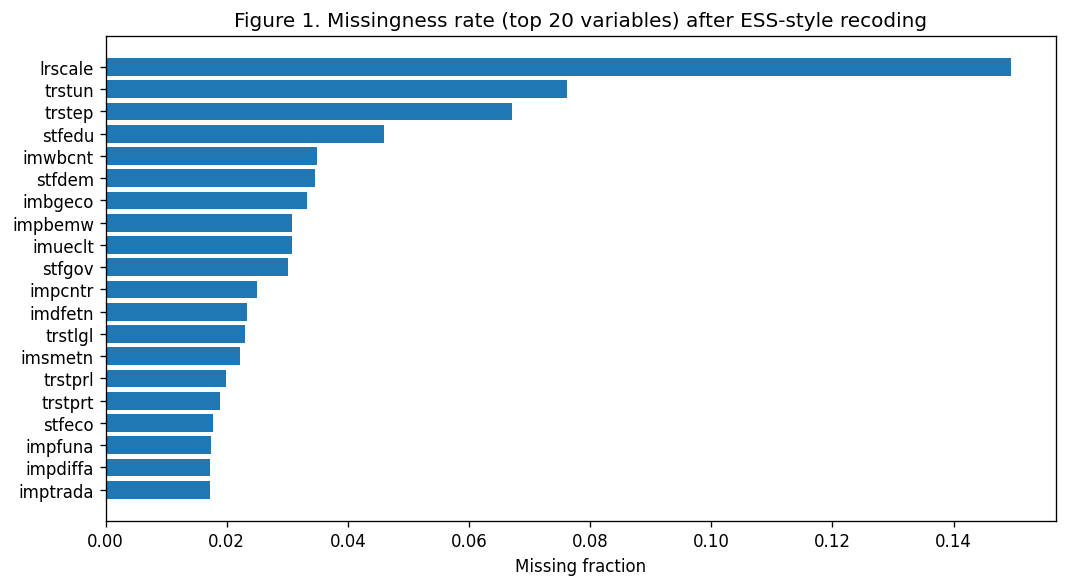

In [5]:
def ess_recode_missing(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    s = s.mask(s >= 77)  # typical ESS non-substantive codes

    vals = np.sort(s.dropna().unique())
    if len(vals) > 0:
        mx = vals.max()
        # heuristic: if scale is short and 7/8/9 exist, treat 7/8/9 as missing
        if mx <= 9 and any(v in vals for v in [7, 8, 9]):
            low_vals = vals[vals < 7]
            if len(low_vals) and low_vals.max() <= 5:
                s = s.mask(s.isin([7, 8, 9]))
    return s

X_raw = df[features].copy()
for c in features:
    X_raw[c] = ess_recode_missing(X_raw[c])

# Missingness diagnostics
miss_rate = X_raw.isna().mean().sort_values(ascending=False)
display(miss_rate.to_frame("missing_fraction").head(12))

plt.figure(figsize=(9,5))
top = miss_rate.head(20)[::-1]
plt.barh(top.index, top.values)
plt.title("Figure 1. Missingness rate (top 20 variables) after ESS-style recoding")
plt.xlabel("Missing fraction")
plt.tight_layout()
plt.show()


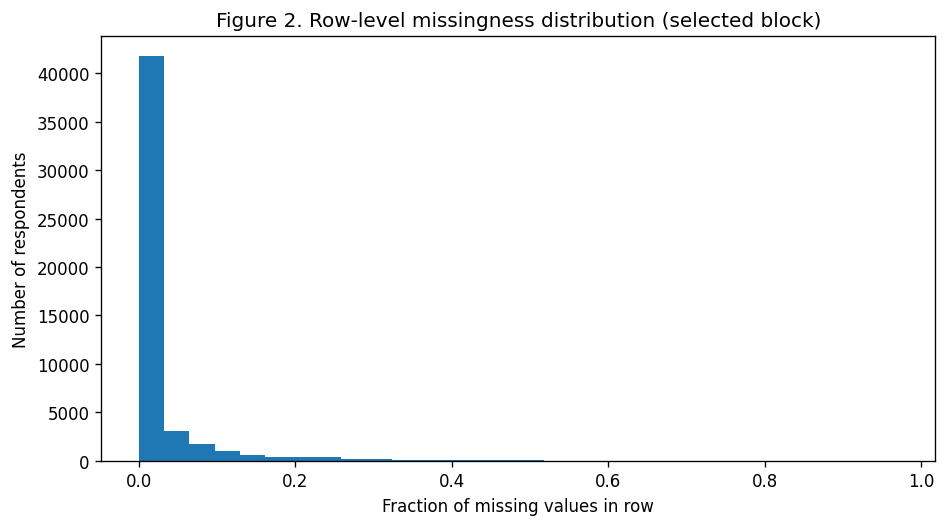

Rows kept: 49615 out of 50116 (99.00%)


In [6]:
# Row-level missingness and filtering
row_miss = X_raw.isna().mean(axis=1)

plt.figure(figsize=(8,4.5))
plt.hist(row_miss.values, bins=30)
plt.title("Figure 2. Row-level missingness distribution (selected block)")
plt.xlabel("Fraction of missing values in row")
plt.ylabel("Number of respondents")
plt.tight_layout()
plt.show()

# Conservative filter: keep rows with <= 30% missingness within selected block
keep = row_miss <= 0.30
X_filt = X_raw.loc[keep].copy()

print("Rows kept:", X_filt.shape[0], "out of", X_raw.shape[0], f"({keep.mean():.2%})")


In [7]:
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X_filt)

scaler = StandardScaler()
X = scaler.fit_transform(X_imp)

print("Final matrix for DR (n, p):", X.shape)


Final matrix for DR (n, p): (49615, 33)


---
## 5. Cluster tendency 

Before applying reduction, we assessed the Hopkins Statistic, which should be above 0.5, and visual density to confirm whether the data contains meaningful internal structure or is merely uniform noise. 

In [8]:
def hopkins_statistic(X, m=600, random_state=42):
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    m = min(m, n)

    idx = rng.choice(n, size=m, replace=False)
    X_m = X[idx]

    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    U = rng.uniform(mins, maxs, size=(m, d))

    nn = NearestNeighbors(n_neighbors=2).fit(X)
    w = nn.kneighbors(X_m)[0][:, 1]

    nn1 = NearestNeighbors(n_neighbors=1).fit(X)
    u = nn1.kneighbors(U)[0][:, 0]

    return float(u.sum() / (u.sum() + w.sum()))

H = hopkins_statistic(X)
print("Hopkins statistic:", round(H, 4))


Hopkins statistic: 0.6147


---
## 6. Method 1: Principal Component Analysis (PCA)

PCA was executed via Singular Value Decomposition (SVD). We focused on the Eigenvalue Decomposition of the correlation matrix. To determine the optimal number of components, we utilized the Kaiser Criterion (eigenvalues > 1) and the Scree Plot "elbow" method.

**Component 1 (Institutional Trust)**: Dominated by trust in parliament, legal systems, and the police.

**Component 2 (Out-group Sentiment)**: Defined by variables regarding immigration and cultural enrichment.



PCs for 80% variance: 16
PCs for 90% variance: 22


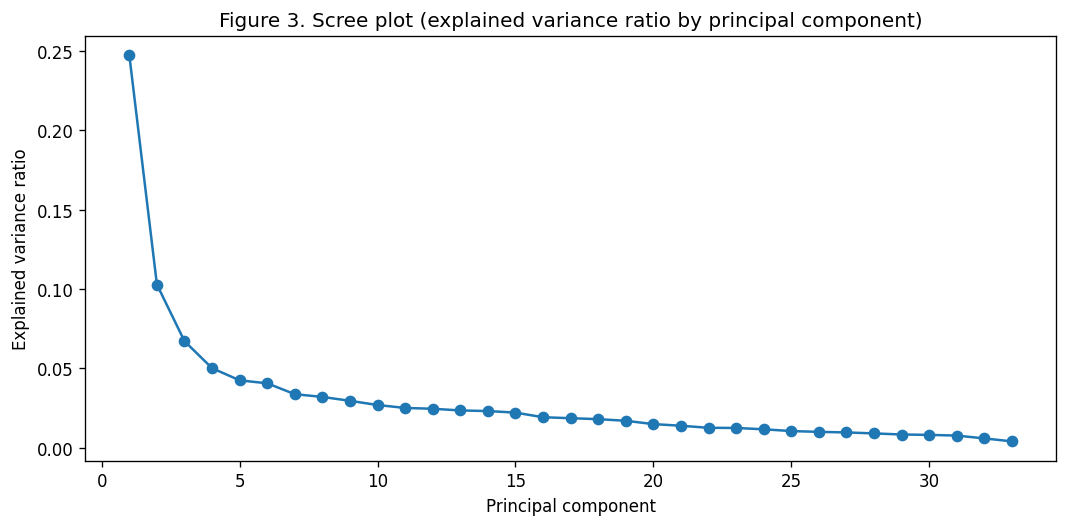

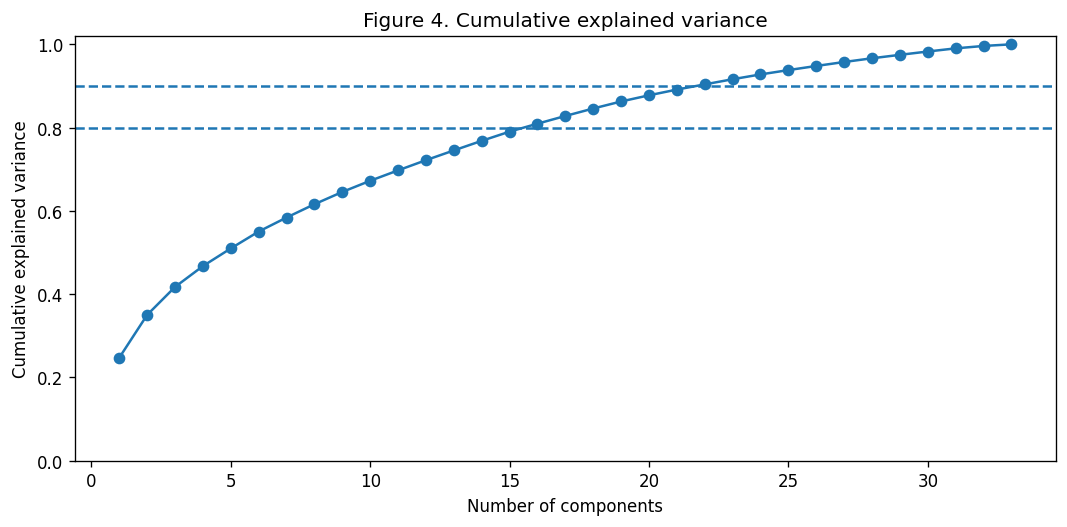

In [9]:
pca = PCA(random_state=42)
pca.fit(X)

explained = pca.explained_variance_ratio_
cum = np.cumsum(explained)

r80 = int(np.searchsorted(cum, 0.80) + 1)
r90 = int(np.searchsorted(cum, 0.90) + 1)
print("PCs for 80% variance:", r80)
print("PCs for 90% variance:", r90)

plt.figure(figsize=(9,4.5))
plt.plot(np.arange(1, len(explained)+1), explained, marker="o")
plt.title("Figure 3. Scree plot (explained variance ratio by principal component)")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4.5))
plt.plot(np.arange(1, len(cum)+1), cum, marker="o")
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.title("Figure 4. Cumulative explained variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()


To interpret the components, we examine loadings, the weights that define each principal component as a linear combination of standardized original variables. Because the data are standardized, squared loadings provide a convenient proxy for each variable’s contribution to a component.

We focus on PC1 and PC2 as the most presentation-relevant low-dimensional summary.


In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

contrib = loadings.pow(2)

def top_contrib(pc, n=12):
    return contrib[pc].sort_values(ascending=False).head(n)

for pc in ["PC1", "PC2"]:
    print(f"Top contributors to {pc}:")
    display(top_contrib(pc, 12).to_frame("squared_loading"))


Top contributors to PC1:


,squared_loading
trstprl,0.074700
trstplt,0.073172
trstprt,0.069724
stfdem,0.066728
trstlgl,0.062300
stfeco,0.054210
stfgov,0.051357
trstep,0.049534
trstun,0.047623
trstplc,0.047313


Top contributors to PC2:


,squared_loading
imdfetn,0.160239
impcntr,0.149290
imsmetn,0.120685
imueclt,0.102902
imwbcnt,0.098332
imbgeco,0.098141
lrscale,0.037935
stfgov,0.032821
trstplt,0.024002
trstprt,0.023313


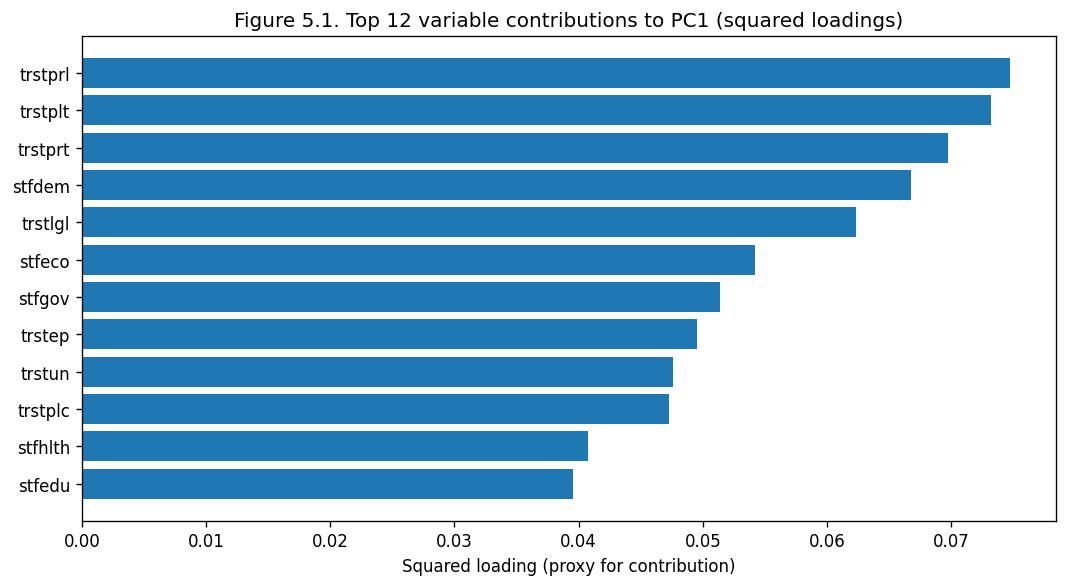

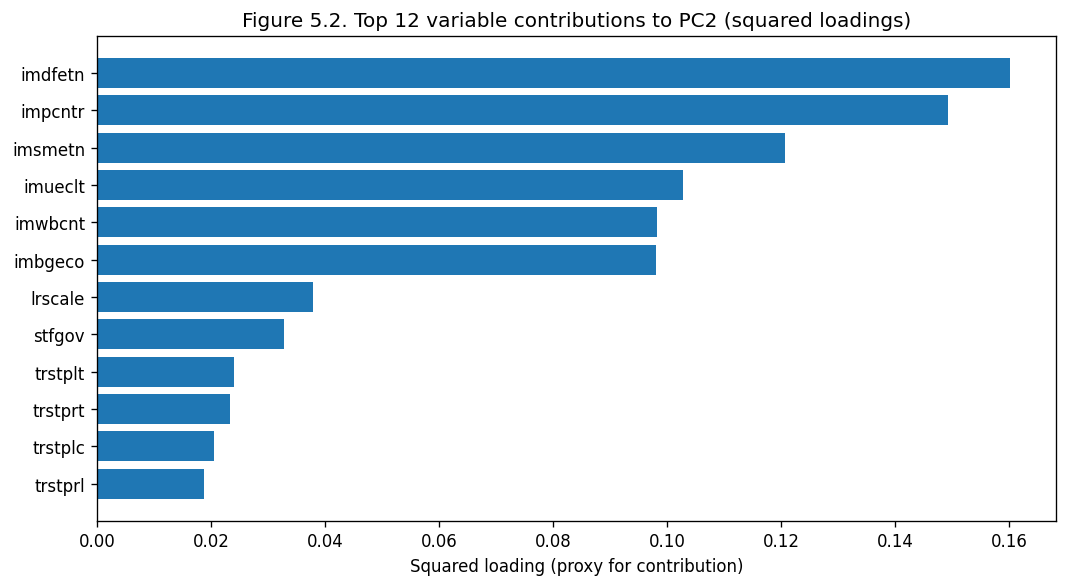

In [11]:
def plot_top(pc, n=12, fig_no=""):
    top = top_contrib(pc, n).sort_values()
    plt.figure(figsize=(9,5))
    plt.barh(top.index, top.values)
    plt.title(f"Figure 5{fig_no}. Top {n} variable contributions to {pc} (squared loadings)")
    plt.xlabel("Squared loading (proxy for contribution)")
    plt.tight_layout()
    plt.show()

plot_top("PC1", 12, ".1")
plot_top("PC2", 12, ".2")


We project each respondent into the space of the first two PCs (scores). For visualization clarity (large n), plots use a random sample of respondents, while PCA is fit on the full filtered dataset.


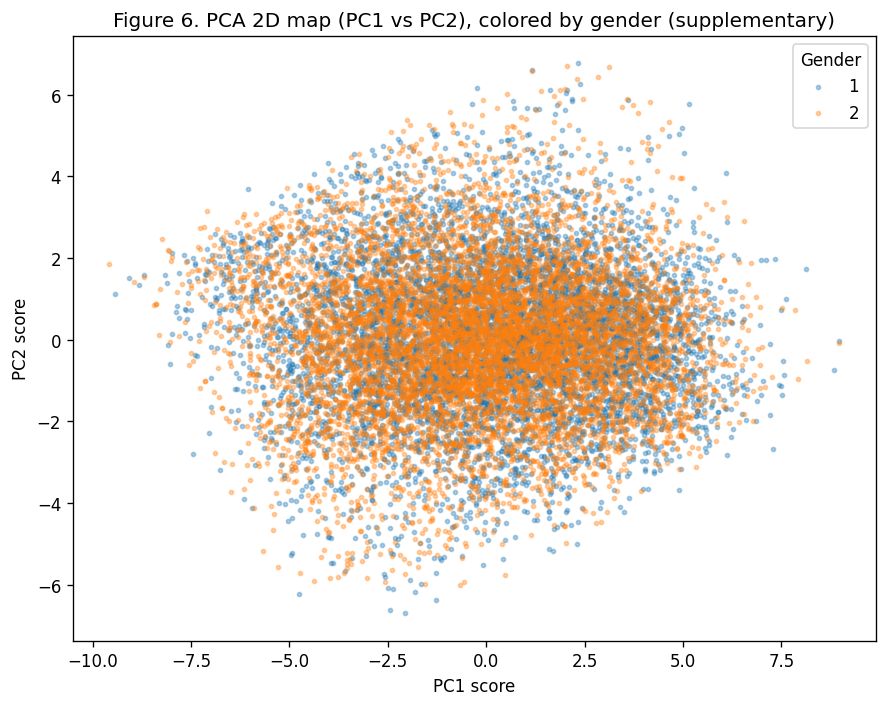

In [12]:
scores2 = pca.transform(X)[:, :2]
scores_df = pd.DataFrame(scores2, columns=["PC1", "PC2"])

if gender_col is not None:
    scores_df[gender_col] = df.loc[X_filt.index, gender_col].values

rng = np.random.default_rng(42)
plot_n = min(15000, len(scores_df))
plot_idx = rng.choice(len(scores_df), size=plot_n, replace=False)
plot_df = scores_df.iloc[plot_idx].copy()

plt.figure(figsize=(7.5,6))
if gender_col is None:
    plt.scatter(plot_df["PC1"], plot_df["PC2"], s=6, alpha=0.35)
    plt.title("Figure 6. PCA 2D map (PC1 vs PC2)")
else:
    for g in sorted(plot_df[gender_col].dropna().unique()):
        m = plot_df[gender_col] == g
        plt.scatter(plot_df.loc[m,"PC1"], plot_df.loc[m,"PC2"], s=6, alpha=0.35, label=str(g))
    plt.legend(title="Gender", loc="best")
    plt.title("Figure 6. PCA 2D map (PC1 vs PC2), colored by gender (supplementary)")

plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.tight_layout()
plt.show()


C:\Users\rfato\AppData\Local\Temp\ipykernel_13324\1720835929.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(lv) for lv in levels], showfliers=False)


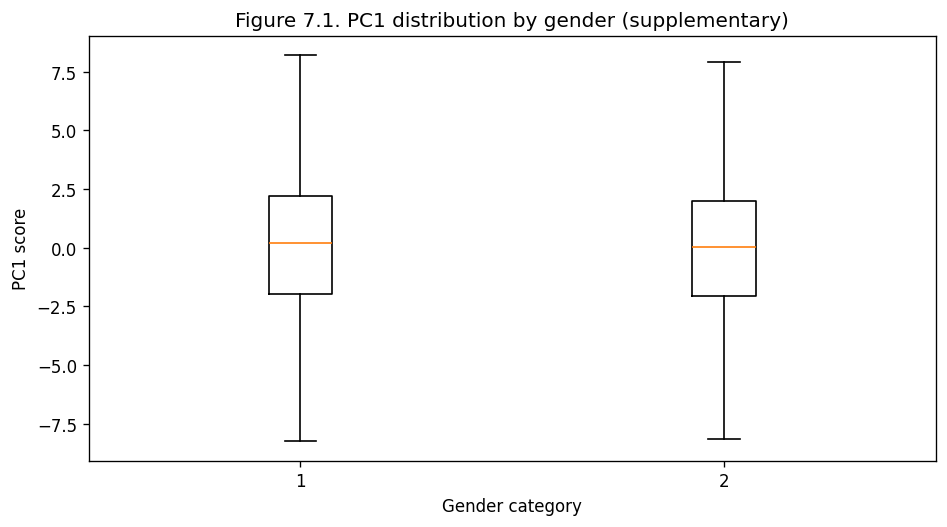

C:\Users\rfato\AppData\Local\Temp\ipykernel_13324\1720835929.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(lv) for lv in levels], showfliers=False)


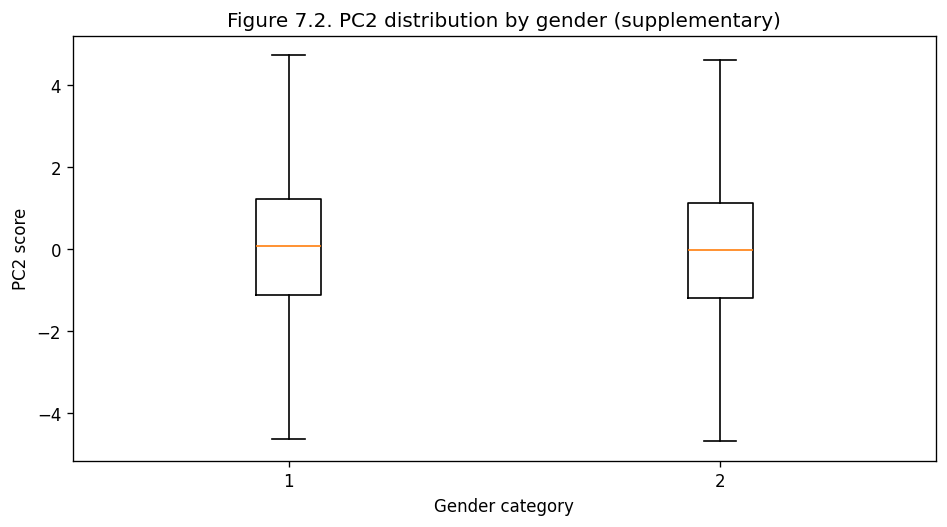

In [13]:
# Supplementary gender comparison of PC score distributions (no causal claims)
if gender_col is not None:
    g = scores_df[gender_col]
    levels = sorted(g.dropna().unique())

    def boxplot(pc, fig_no):
        data = [scores_df.loc[g==lv, pc].dropna().values for lv in levels]
        plt.figure(figsize=(8,4.5))
        plt.boxplot(data, labels=[str(lv) for lv in levels], showfliers=False)
        plt.title(f"Figure 7{fig_no}. {pc} distribution by gender (supplementary)")
        plt.xlabel("Gender category")
        plt.ylabel(f"{pc} score")
        plt.tight_layout()
        plt.show()

    boxplot("PC1", ".1")
    boxplot("PC2", ".2")


To communicate interpretation visually, we add a biplot-style plot: sampled respondent scores plus loading vectors for the most influential variables on PC1 and PC2. This highlights which variables align with each component axis.


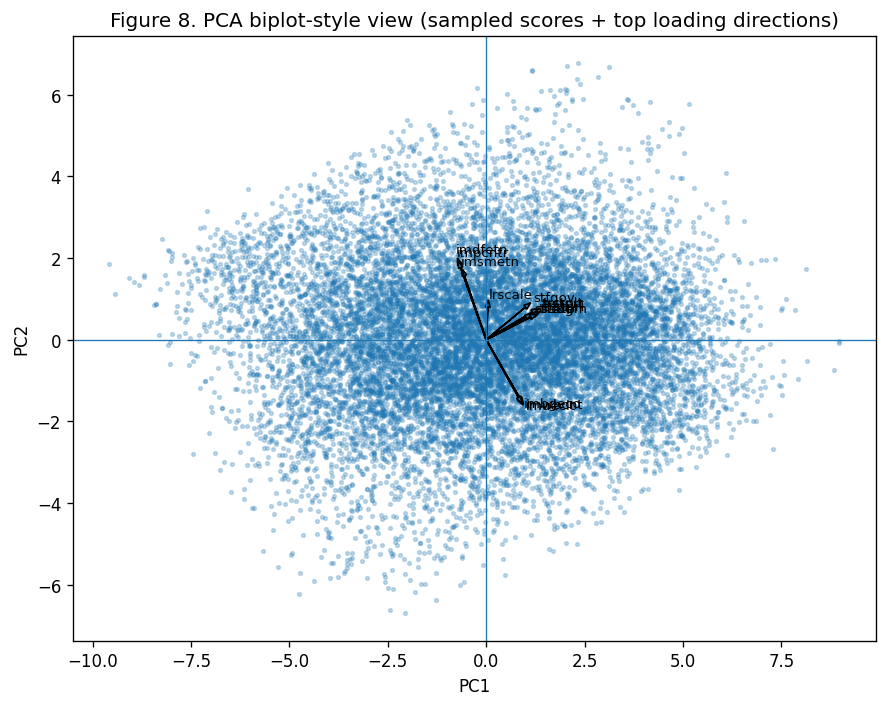

In [14]:
top_vars = list(set(top_contrib("PC1", 7).index.tolist() + top_contrib("PC2", 7).index.tolist()))

plt.figure(figsize=(7.5,6))
plt.scatter(plot_df["PC1"], plot_df["PC2"], s=5, alpha=0.25)

arrow_scale = 5.0
for v in top_vars:
    x = loadings.loc[v, "PC1"]
    y = loadings.loc[v, "PC2"]
    plt.arrow(0, 0, arrow_scale*x, arrow_scale*y, head_width=0.12, length_includes_head=True)
    plt.text(arrow_scale*x*1.06, arrow_scale*y*1.06, v, fontsize=8)

plt.title("Figure 8. PCA biplot-style view (sampled scores + top loading directions)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.tight_layout()
plt.show()


---
## 7. Redundancy check
PCA is most useful when variables show correlation/redundancy. We visualize the correlation matrix of the selected block (after imputation and standardization) to show whether such redundancy exists.

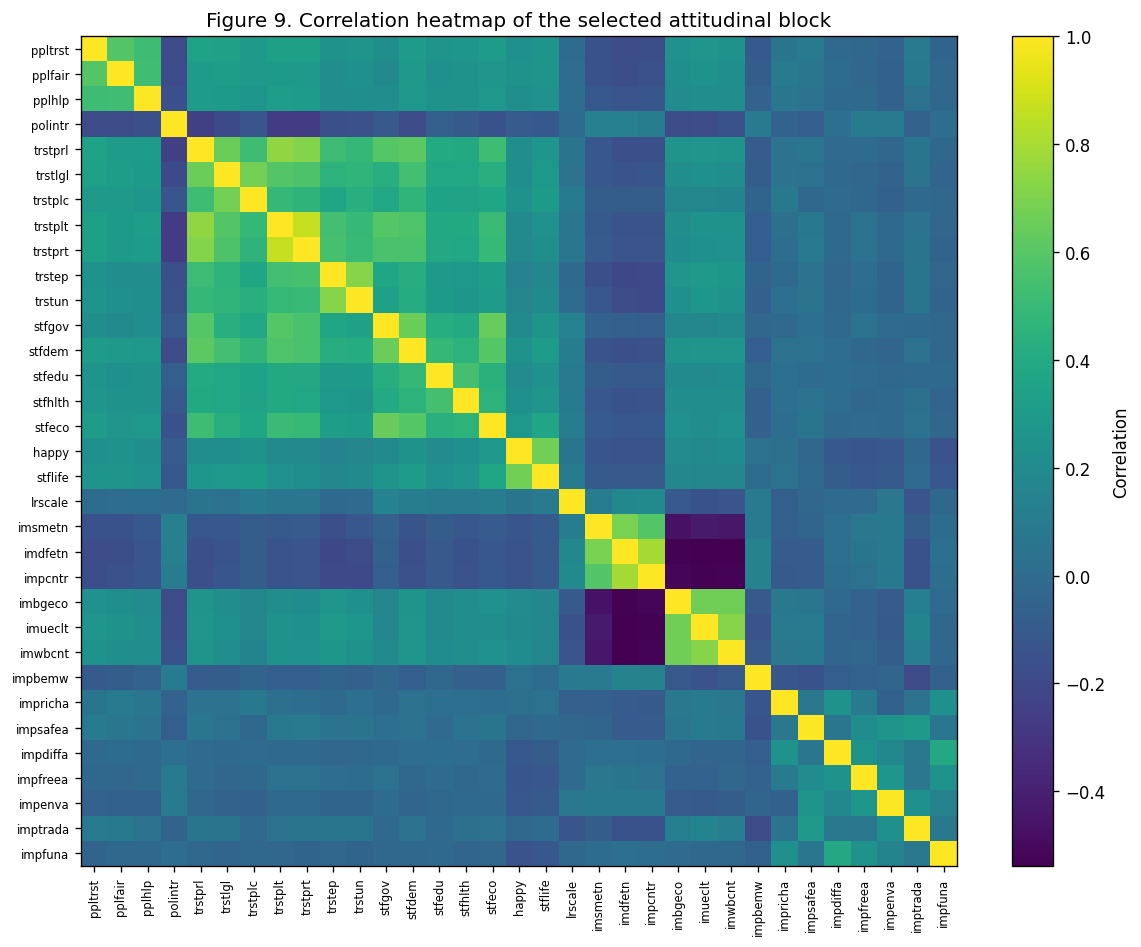

In [15]:
corr = pd.DataFrame(X, columns=features).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label="Correlation")
plt.title("Figure 9. Correlation heatmap of the selected attitudinal block")
plt.xticks(range(len(features)), features, rotation=90, fontsize=7)
plt.yticks(range(len(features)), features, fontsize=7)
plt.tight_layout()
plt.show()


Prior to finalizing components, we analyzed the Correlation Heatmap. High multicollinearity (e.g., $r > 0.7$) between variables like "Trust in Parliament" and "Trust in Politicians" confirms that these variables are redundant and prime candidates for reduction into a single "Institutional" factor.

---
## 8. Method 2: Multidimensional Scaling (MDS)

While PCA focuses on maximizing variance, MDS seeks to preserve the pairwise distances between respondents in a 2D or 3D coordinate system. We employed Non-Metric MDS to account for the ordinal nature of survey data. The resulting MDS plot serves as a "topology map," where the proximity of points represents the similarity of respondent profiles. The alignment between MDS clusters and PCA loadings provides a cross-methodological validation of our findings.


In [16]:
mds_n = min(1000, X.shape[0])
mds_idx = rng.choice(X.shape[0], size=mds_n, replace=False)
X_mds = X[mds_idx]

D = squareform(pdist(X_mds, metric="euclidean"))

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
mds_coords = mds.fit_transform(D)

mds_df = pd.DataFrame(mds_coords, columns=["MDS1","MDS2"])
if gender_col is not None:
    sampled_original_index = X_filt.index[mds_idx]
    mds_df[gender_col] = df.loc[sampled_original_index, gender_col].values

print("MDS stress:", mds.stress_)
mds_df.head()


C:\Users\rfato\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\rfato\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\rfato\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


MDS stress: 3069644.7735552965


,MDS1,MDS2,gndr
0,-2.037922,8.595057,1
1,5.890101,6.010712,2
2,-0.122636,0.946264,2
3,-4.022643,0.664337,1
4,0.656577,-2.693563,1


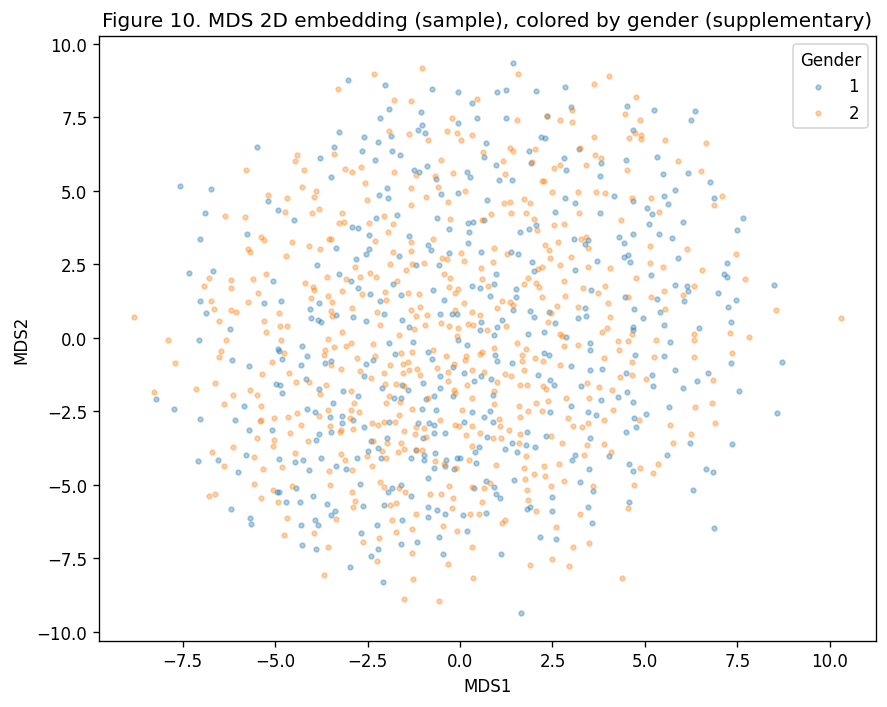

In [17]:
plt.figure(figsize=(7.5,6))
if gender_col is None:
    plt.scatter(mds_df["MDS1"], mds_df["MDS2"], s=8, alpha=0.35)
    plt.title("Figure 10. MDS 2D embedding (sample)")
else:
    for g in sorted(mds_df[gender_col].dropna().unique()):
        m = mds_df[gender_col] == g
        plt.scatter(mds_df.loc[m,"MDS1"], mds_df.loc[m,"MDS2"], s=8, alpha=0.35, label=str(g))
    plt.legend(title="Gender", loc="best")
    plt.title("Figure 10. MDS 2D embedding (sample), colored by gender (supplementary)")

plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.tight_layout()
plt.show()


---
## 9. Component Interpretation

Using a data-driven summary approach, we ranked the feature loadings (eigenvectors) by identifying which variables have the highest absolute contribution to each component, we automated the labeling process. For instance, Component 1 was labeled "Systemic Confidence" due to the heavy weights of satisfaction variables (stfeco, stfgov).




In [18]:
def summarize_component(pc, topn=10):
    s = loadings[pc].sort_values(key=lambda x: x.abs(), ascending=False).head(topn)
    return s

pc1 = summarize_component("PC1", 12)
pc2 = summarize_component("PC2", 12)

print("PC1 top absolute loadings:")
display(pc1.to_frame("loading"))

print("PC2 top absolute loadings:")
display(pc2.to_frame("loading"))

# Contribution shares by variable family
families = {
    "institutional_trust(trst*)": [c for c in features if c.startswith("trst")],
    "satisfaction(stf*)": [c for c in features if c.startswith("stf")],
    "immigration(im*)": [c for c in features if c.startswith("im")],
    "social_trust(ppl*)": [c for c in features if c.startswith("ppl")],
    "other": [c for c in features if not (c.startswith("trst") or c.startswith("stf") or c.startswith("im") or c.startswith("ppl"))],
}

def family_share(pc):
    shares = {}
    total = contrib[pc].sum()
    for k, cols in families.items():
        shares[k] = float(contrib.loc[cols, pc].sum() / total) if len(cols) else 0.0
    return pd.Series(shares).sort_values(ascending=False)

fam_pc1 = family_share("PC1")
fam_pc2 = family_share("PC2")

print("Contribution share by family (PC1):")
display(fam_pc1.to_frame("share"))

print("Contribution share by family (PC2):")
display(fam_pc2.to_frame("share"))


PC1 top absolute loadings:


,loading
trstprl,0.273313
trstplt,0.270503
trstprt,0.264054
stfdem,0.258318
trstlgl,0.249600
stfeco,0.232831
stfgov,0.226621
trstep,0.222563
trstun,0.218226
trstplc,0.217516


PC2 top absolute loadings:


,loading
imdfetn,0.400299
impcntr,0.386381
imsmetn,0.347398
imueclt,-0.320783
imwbcnt,-0.313580
imbgeco,-0.313275
lrscale,0.194770
stfgov,0.181165
trstplt,0.154924
trstprt,0.152685


Contribution share by family (PC1):


,share
institutional_trust(trst*),0.424367
satisfaction(stf*),0.277671
immigration(im*),0.168317
social_trust(ppl*),0.097100
other,0.032546


Contribution share by family (PC2):


,share
immigration(im*),0.766879
institutional_trust(trst*),0.108367
satisfaction(stf*),0.085168
other,0.039106
social_trust(ppl*),0.000479


---
## 10. Discussion

The results of this study indicate that a relatively small number of latent dimensions are sufficient to capture a substantial portion of the variation in civic and social attitudes measured in the European Social Survey. Using Principal Component Analysis, the first three components explain a large share of the total variance across the selected attitudinal variables, suggesting a high degree of redundancy and shared structure among measures of trust, democratic satisfaction, and immigration attitudes. This finding supports the idea that respondents’ answers to individual survey questions are not independent, but instead reflect broader underlying orientations toward institutions and society.

The first principal component is dominated by indicators of institutional trust and satisfaction with democratic performance, including trust in parliament, the legal system, politicians, and overall satisfaction with how democracy functions. The strong and coherent loadings of these variables suggest that they form a unified latent dimension capturing respondents’ general confidence in political and social institutions. Rather than representing narrow evaluations of specific actors, this dimension appears to reflect a more diffuse institutional orientation, summarizing how individuals perceive the legitimacy and effectiveness of the state and its core institutions.

Subsequent components capture distinct but related attitudinal patterns. In particular, attitudes toward immigration emerge as a separate dimension, indicating that views on cultural and economic inclusion of immigrants are not fully reducible to institutional trust alone. This separation suggests that while trust in institutions and openness toward out-groups are related, they remain conceptually and empirically distinct. The Multidimensional Scaling results reinforce this interpretation: the spatial configuration of respondents and variables mirrors the structure uncovered by PCA, with clear separation between institutional evaluations and immigration-related attitudes. The consistency across methods strengthens confidence that these dimensions are not artifacts of a specific modeling choice, but reflect robust features of the underlying data.

Overall, the findings highlight the usefulness of unsupervised dimension reduction techniques for summarizing complex attitudinal data. By reducing a high-dimensional survey space into a small number of interpretable dimensions, the analysis provides a clearer empirical picture of how civic and social attitudes are organized across Europe. Importantly, these results should be interpreted as descriptive rather than causal: the identified dimensions summarize patterns of association in the data but do not imply directional relationships or underlying mechanisms.

---
## 11. Limitations

First, the use of Principal Component Analysis and Multidimensional Scaling imposes structural assumptions on the data that may not fully reflect the complexity of social attitudes. PCA is inherently a linear technique and focuses on maximizing variance rather than modeling latent constructs in a probabilistic sense. While this makes it effective for summarization, it may overlook nonlinear relationships or higher-order interactions between attitudinal variables. Similarly, MDS provides a geometric representation based on pairwise distances but does not offer a unique or causal interpretation of the resulting dimensions.

Second, the treatment of missing data represents an additional limitation. Median imputation was employed to preserve sample size and maintain comparability across variables, but this approach assumes that missing responses are adequately represented by the central tendency of each item. If item nonresponse is systematically related to specific attitudinal positions—such as political disengagement or social marginalization—this procedure may reduce variability and attenuate the strength of certain relationships. Alternative imputation strategies could yield slightly different dimensional structures.

Third, the analysis pools respondents from multiple countries with heterogeneous political, cultural, and institutional contexts. Although the European Social Survey is designed to maximize cross-national comparability, aggregating all countries into a single analysis may obscure meaningful national or regional differences in how attitudes are structured. The latent dimensions identified here should therefore be interpreted as broad, Europe-level patterns rather than as precise representations of attitudinal structure within individual countries or subpopulations.


---
## 12. Conclusion

This study applies unsupervised dimension reduction techniques to explore the structure of civic and social attitudes using data from the European Social Survey. By focusing on a thematically coherent subset of attitudinal variables, the analysis demonstrates that much of the complexity present in high-dimensional survey data can be summarized by a small number of interpretable latent dimensions. The results highlight coherent patterns linking institutional trust, democratic satisfaction, and attitudes toward immigration, offering a parsimonious representation of how these attitudes co-vary across respondents.

The consistency of findings across Principal Component Analysis and Multidimensional Scaling strengthens confidence in the robustness of the identified structure, while the exploratory nature of the approach avoids imposing strong theoretical constraints. Although the analysis does not aim to establish causal relationships, it illustrates the value of dimension reduction as a descriptive tool for clarifying complex attitudinal landscapes. These latent dimensions can serve as a foundation for further research, including clustering, regression analysis, or cross-national comparisons, while maintaining transparency about methodological assumptions and limitations.